In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving HHS_Unaccompanied_Alien_Children_Program.csv to HHS_Unaccompanied_Alien_Children_Program.csv


In [3]:
df = pd.read_csv("/content/HHS_Unaccompanied_Alien_Children_Program.csv")

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1170
Columns: 6


In [5]:
print(df.columns)

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [7]:
df = df.dropna(how="all")

print("Rows after removing blank rows:", len(df))

Rows after removing blank rows: 720


**Convert into datetime format**

In [8]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print(df["Date"].head())

0   2025-12-21
1   2025-12-18
2   2025-12-17
3   2025-12-16
4   2025-12-15
Name: Date, dtype: datetime64[ns]


**Convert into numeric**

In [9]:
numeric_columns = [
    "Children apprehended and placed in CBP custody*",
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

for col in numeric_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("nan", np.nan)
        .astype(float)
    )

In [10]:
df = df.dropna(subset=["Date"])

df = df.sort_values("Date")

df = df.reset_index(drop=True)

print(df.shape)

(720, 6)


In [11]:
print(df.isnull().sum())

Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64


In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


**Statistical summary**

In [13]:
df.describe()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
count,720,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2024-07-06 05:29:59.999999744,93.523611,171.494444,128.668056,6061.275000,173.406944
min,2023-01-12 00:00:00,0.000000,7.000000,0.000000,1972.000000,0.000000
25%,2023-10-16 18:00:00,12.000000,36.000000,14.000000,2467.750000,19.750000
50%,2024-07-05 12:00:00,99.000000,193.000000,157.000000,6406.500000,181.000000
75%,2025-03-25 06:00:00,147.250000,263.250000,199.250000,8010.250000,267.000000
max,2025-12-21 00:00:00,333.000000,531.000000,440.000000,11516.000000,505.000000
std,NaN,72.646625,126.354965,97.322012,2833.070109,125.702841


**VALIDATION**

Transfer validation

In [14]:
df["Transfer_Valid"] = (
    df["Children transferred out of CBP custody"]
    <= df["Children in CBP custody"]
)

print(df["Transfer_Valid"].value_counts())

Transfer_Valid
True     634
False     86
Name: count, dtype: int64


Discharge validation

In [15]:
df["Discharge_Valid"] = (
    df["Children discharged from HHS Care"]
    <= df["Children in HHS Care"]
)

print(df["Discharge_Valid"].value_counts())

Discharge_Valid
True    720
Name: count, dtype: int64


Invalid records

In [16]:
invalid_records = df[
    (~df["Transfer_Valid"]) |
    (~df["Discharge_Valid"])
]

print("Invalid records:", len(invalid_records))

Invalid records: 86


**DAILY ANALYSIS**

Average CBP custody

In [17]:
print(
    "Average CBP Custody:",
    df["Children in CBP custody"].mean()
)

Average CBP Custody: 171.49444444444444


Average HHS Care

In [18]:
print(
    "Average HHS Care:",
    df["Children in HHS Care"].mean()
)

Average HHS Care: 6061.275


Minimum and Maximum HHS Care

In [19]:
print("Minimum HHS Care:",
      df["Children in HHS Care"].min())

print("Maximum HHS Care:",
      df["Children in HHS Care"].max())

Minimum HHS Care: 1972.0
Maximum HHS Care: 11516.0


**Daily Trend: CBP Custody**

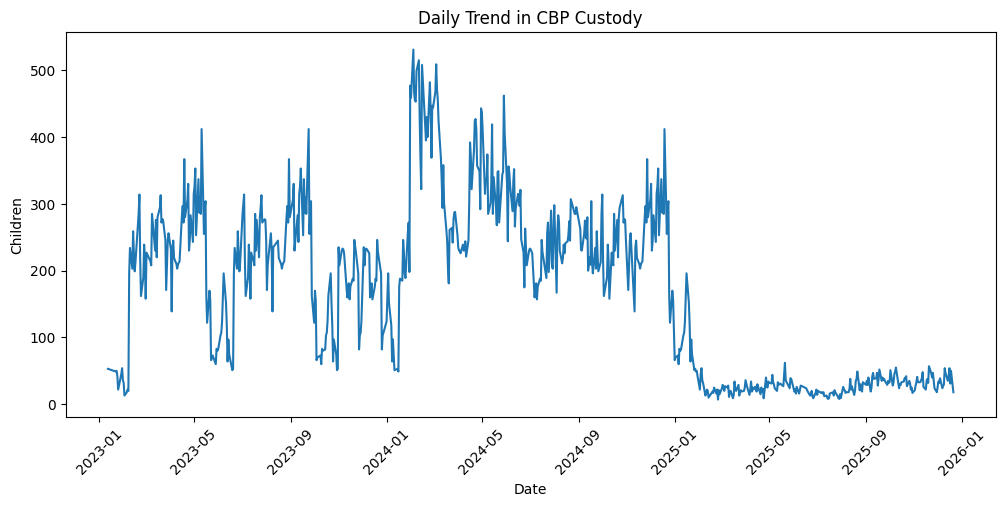

In [20]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Children in CBP custody"]
)

plt.title("Daily Trend in CBP Custody")
plt.xlabel("Date")
plt.ylabel("Children")

plt.xticks(rotation=45)
plt.show()

**Daily Trend: HHS Care**

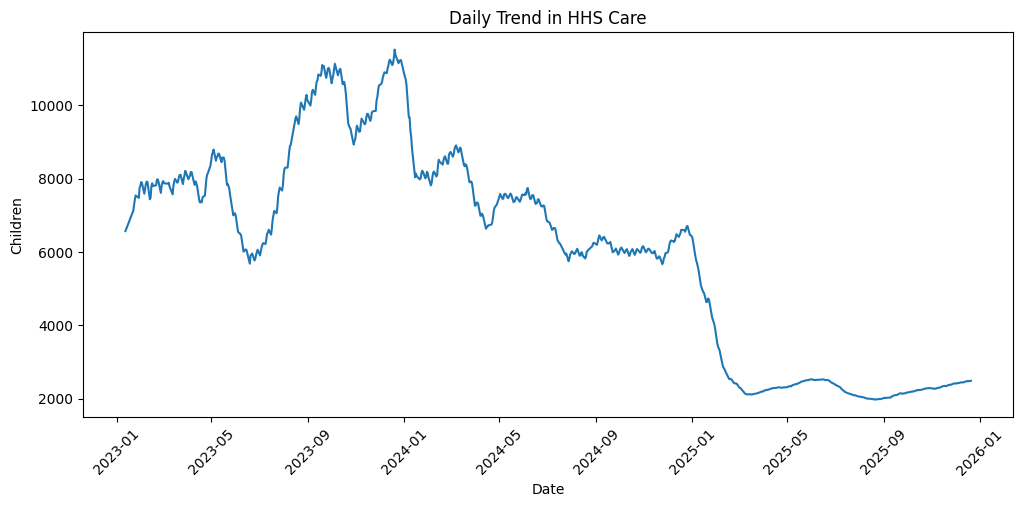

In [21]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Children in HHS Care"]
)

plt.title("Daily Trend in HHS Care")
plt.xlabel("Date")
plt.ylabel("Children")

plt.xticks(rotation=45)
plt.show()

**MONTHLY ANALYSIS**

In [22]:
df["Month"] = df["Date"].dt.to_period("M")

Monthly average

In [23]:
monthly_avg = df.groupby("Month")[
    [
        "Children in CBP custody",
        "Children in HHS Care"
    ]
].mean()

monthly_avg.head()

,Children in CBP custody,Children in HHS Care
Month,,
2023-01,43.875000,7369.625000
2023-02,171.315789,7795.789474
2023-03,245.105263,7945.368421
2023-04,250.190476,7842.666667
2023-05,216.954545,8187.136364


Monthly trend graph

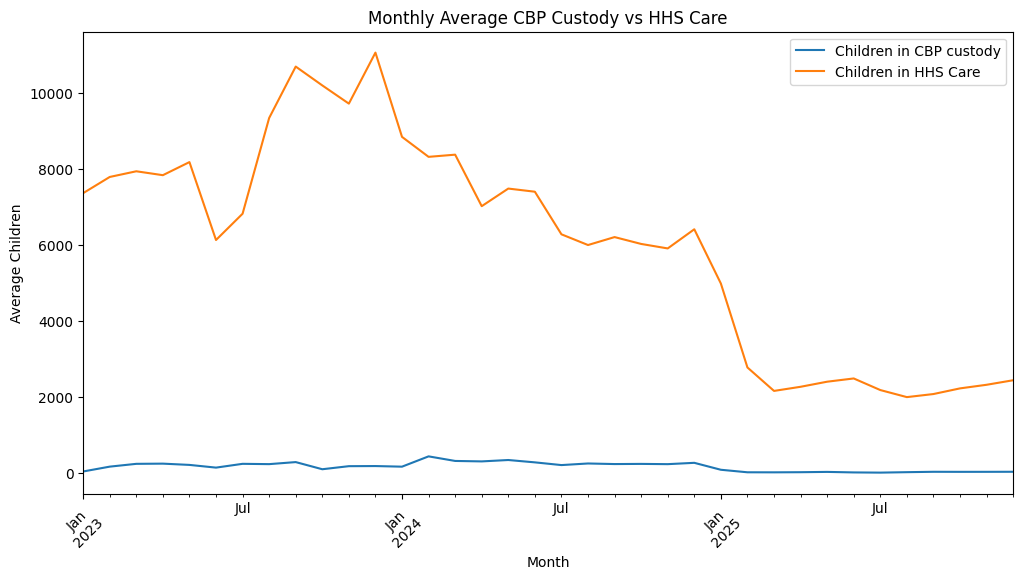

In [24]:
monthly_avg.plot(
    figsize=(12,6)
)

plt.title("Monthly Average CBP Custody vs HHS Care")
plt.xlabel("Month")
plt.ylabel("Average Children")

plt.xticks(rotation=45)
plt.show()

**TOTAL SYSTEM LOAD**

In [25]:
df["Total System Load"] = (
    df["Children in CBP custody"]
    + df["Children in HHS Care"]
)

In [26]:
df[
    [
        "Date",
        "Children in CBP custody",
        "Children in HHS Care",
        "Total System Load"
    ]
].head()

,Date,Children in CBP custody,Children in HHS Care,Total System Load
0,2023-01-12,53.0,6566.0,6619.0
1,2023-01-22,49.0,7122.0,7171.0
2,2023-01-23,50.0,7280.0,7330.0
3,2023-01-24,42.0,7433.0,7475.0
4,2023-01-25,22.0,7538.0,7560.0


**Total System Load graph**

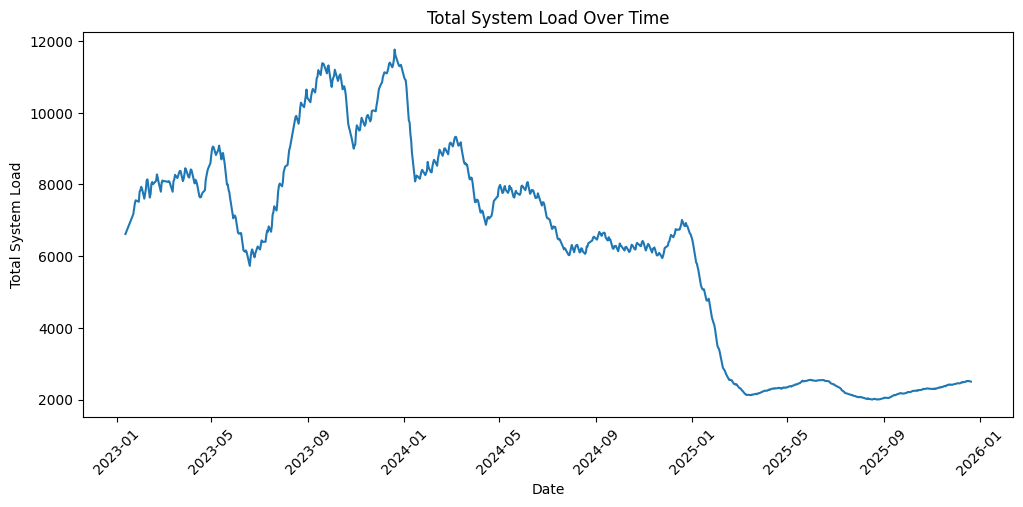

In [27]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Total System Load"]
)

plt.title("Total System Load Over Time")
plt.xlabel("Date")
plt.ylabel("Total System Load")

plt.xticks(rotation=45)
plt.show()

**NET INTAKE**

In [28]:
df["Net Intake"] = (
    df["Children apprehended and placed in CBP custody*"]
    - df["Children transferred out of CBP custody"]
    - df["Children discharged from HHS Care"]
)

In [29]:
df[["Date", "Net Intake"]].head()

,Date,Net Intake
0,2023-01-12,-437.0
1,2023-01-22,-234.0
2,2023-01-23,-188.0
3,2023-01-24,-175.0
4,2023-01-25,-201.0


**Net Intake graph**

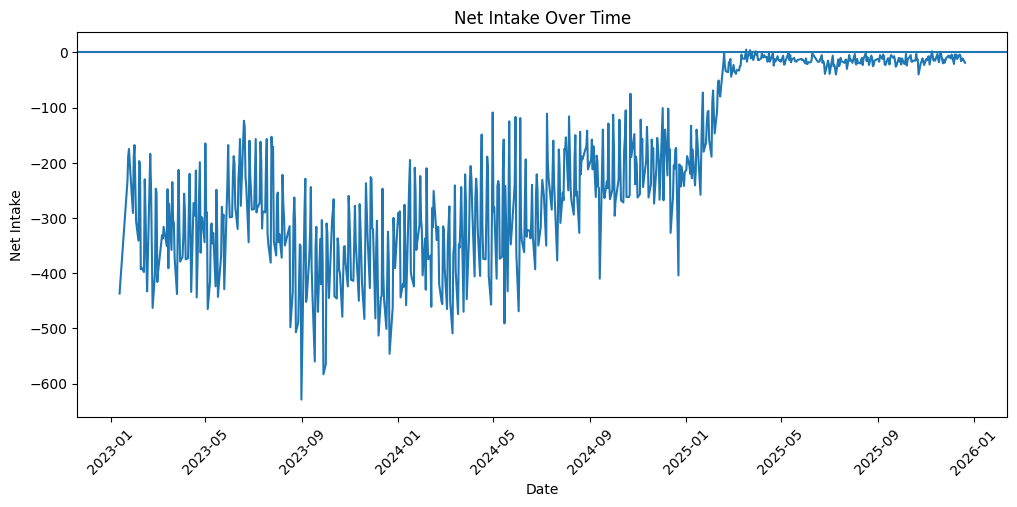

In [30]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Net Intake"]
)

plt.axhline(0)

plt.title("Net Intake Over Time")
plt.xlabel("Date")
plt.ylabel("Net Intake")

plt.xticks(rotation=45)
plt.show()

**GROWTH RATE**

In [31]:
df["Load Growth Rate"] = (
    df["Total System Load"].pct_change() * 100
)

**Growth graph**

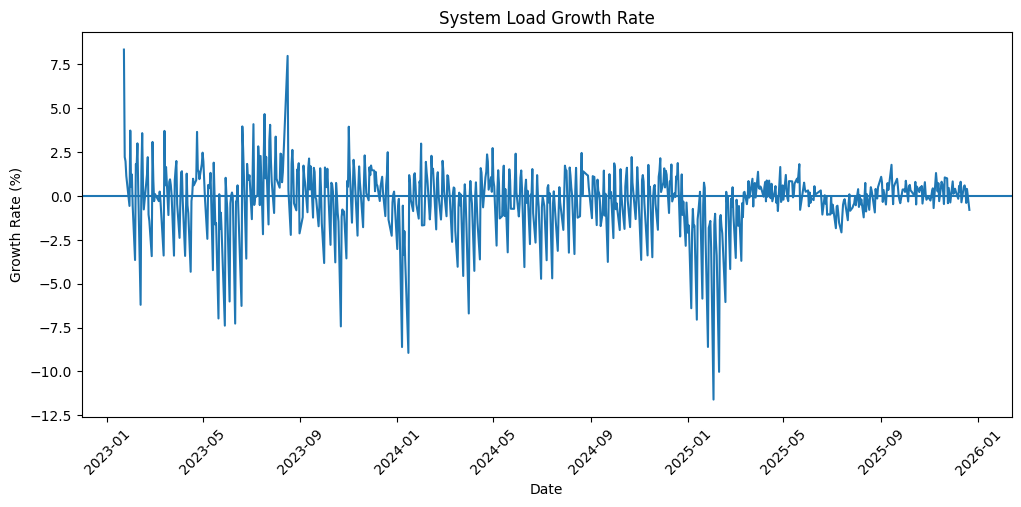

In [32]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Load Growth Rate"]
)

plt.axhline(0)

plt.title("System Load Growth Rate")
plt.xlabel("Date")
plt.ylabel("Growth Rate (%)")

plt.xticks(rotation=45)
plt.show()

**ROLLING AVERAGES**

In [33]:
df["7-Day Rolling Average"] = (
    df["Total System Load"]
    .rolling(7)
    .mean()
)

df["14-Day Rolling Average"] = (
    df["Total System Load"]
    .rolling(14)
    .mean()
)

**Rolling Average Graph**

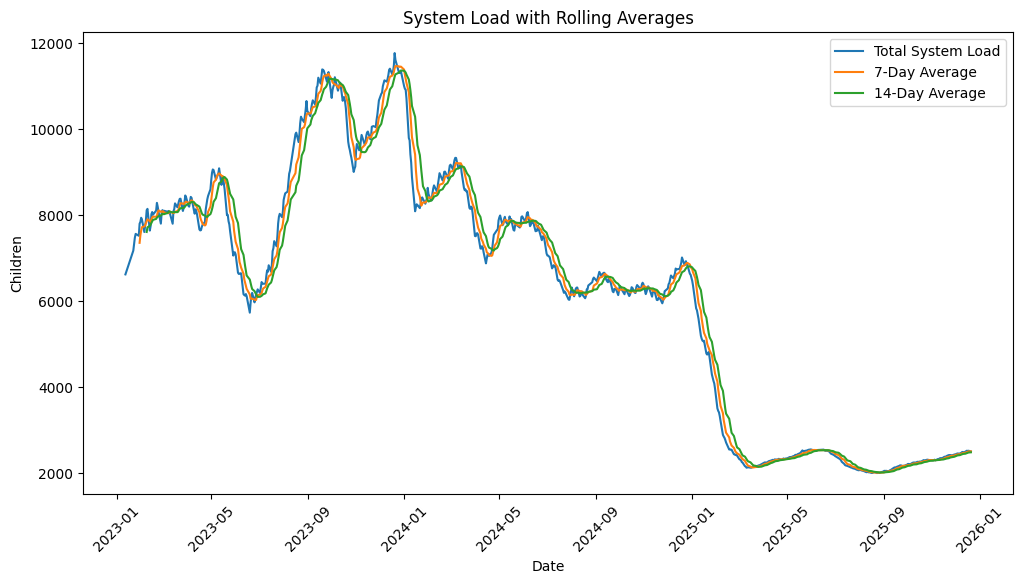

In [34]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Date"],
    df["Total System Load"],
    label="Total System Load"
)

plt.plot(
    df["Date"],
    df["7-Day Rolling Average"],
    label="7-Day Average"
)

plt.plot(
    df["Date"],
    df["14-Day Rolling Average"],
    label="14-Day Average"
)

plt.title("System Load with Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Children")

plt.legend()
plt.xticks(rotation=45)

plt.show()

**CBP VS HHS**

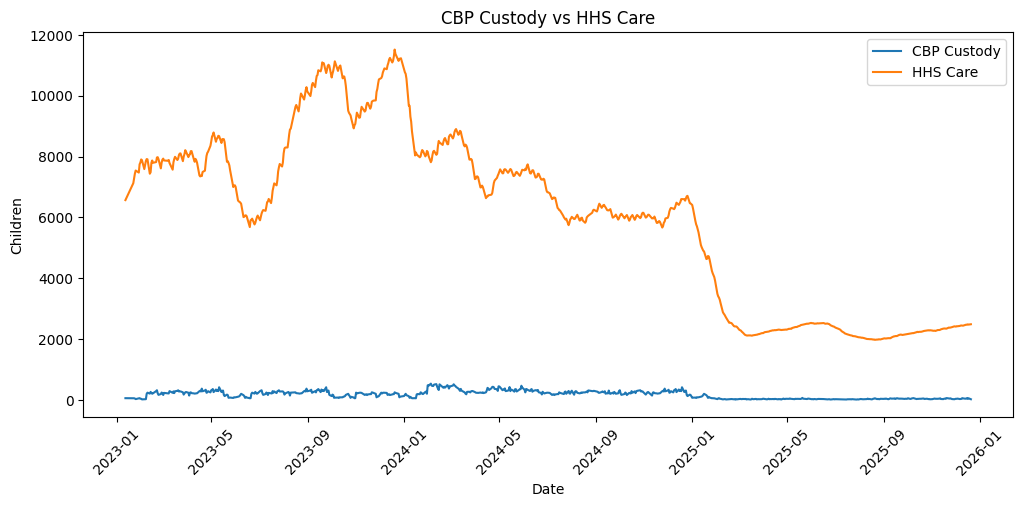

In [35]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Children in CBP custody"],
    label="CBP Custody"
)

plt.plot(
    df["Date"],
    df["Children in HHS Care"],
    label="HHS Care"
)

plt.title("CBP Custody vs HHS Care")
plt.xlabel("Date")
plt.ylabel("Children")

plt.legend()
plt.xticks(rotation=45)

plt.show()

**PROLONGED SYSTEM STRAIN**

In [36]:
average_load = df["Total System Load"].mean()

print("Average System Load:", average_load)

Average System Load: 6232.769444444444


In [37]:
df["System Strain"] = (
    df["Total System Load"] > average_load
)

**Prolonged strain days**

In [38]:
prolonged_strain_days = df["System Strain"].sum()

print(
    "Prolonged Strain Days:",
    prolonged_strain_days
)

Prolonged Strain Days: 429


In [39]:
strain_percentage = (
    prolonged_strain_days / len(df) * 100
)

print(
    "Prolonged Strain Percentage:",
    round(strain_percentage, 2),
    "%"
)

Prolonged Strain Percentage: 59.58 %


**VARIABILITY**

In [40]:
print(
    "Standard Deviation of System Load:",
    df["Total System Load"].std()
)

Standard Deviation of System Load: 2918.458078259615


**PROJECT KPIs**

In [41]:
print("===== PROJECT KPIs =====")

print(
    "Average CBP Custody:",
    round(df["Children in CBP custody"].mean(), 2)
)

print(
    "Average HHS Care:",
    round(df["Children in HHS Care"].mean(), 2)
)

print(
    "Average Total System Load:",
    round(df["Total System Load"].mean(), 2)
)

print(
    "Maximum Total System Load:",
    df["Total System Load"].max()
)

print(
    "Minimum Total System Load:",
    df["Total System Load"].min()
)

print(
    "Average Net Intake:",
    round(df["Net Intake"].mean(), 2)
)

print(
    "Prolonged Strain Days:",
    df["System Strain"].sum()
)

print(
    "Prolonged Strain Percentage:",
    round(
        df["System Strain"].mean() * 100,
        2
    ),
    "%"
)

===== PROJECT KPIs =====
Average CBP Custody: 171.49
Average HHS Care: 6061.28
Average Total System Load: 6232.77
Maximum Total System Load: 11762.0
Minimum Total System Load: 2002.0
Average Net Intake: -208.55
Prolonged Strain Days: 429
Prolonged Strain Percentage: 59.58 %


**TOP 10 HIGHEST LOAD DAYS**

In [42]:
top_load_days = df.nlargest(
    10,
    "Total System Load"
)

top_load_days[
    [
        "Date",
        "Children in CBP custody",
        "Children in HHS Care",
        "Total System Load"
    ]
]

,Date,Children in CBP custody,Children in HHS Care,Total System Load
224,2023-12-20,246.0,11516.0,11762.0
225,2023-12-21,228.0,11375.0,11603.0
223,2023-12-19,185.0,11291.0,11476.0
220,2023-12-14,157.0,11242.0,11399.0
161,2023-09-19,287.0,11095.0,11382.0
162,2023-09-20,310.0,11064.0,11374.0
219,2023-12-13,181.0,11192.0,11373.0
163,2023-09-21,285.0,11067.0,11352.0
226,2023-12-25,196.0,11144.0,11340.0
222,2023-12-18,188.0,11149.0,11337.0


**SAVE CLEANED DATA**

In [43]:
df.to_csv(
    "Cleaned_HHS_Unaccompanied_Children.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [44]:
from google.colab import files

files.download(
    "Cleaned_HHS_Unaccompanied_Children.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Final Findings

1. The average number of children in CBP custody was **171.49**, while the average number of children in HHS Care was **6061.28**. This shows that HHS Care accounted for the major portion of the overall system load.

2. The average Total System Load was **6232.77 children**, with a maximum of **11762 children** and a minimum of **2002 children** during the analysed period. This indicates considerable variation in the overall system load.

3. The average Net Intake was **-208.55**, indicating that transfers and discharges were higher than new intake on average during the analysed period.

4. The system experienced **429 prolonged strain days**, representing approximately **59.58%** of the analysed days. This indicates that the system frequently operated above its average load level.

5. The 7-day and 14-day rolling averages help identify longer-term system-load patterns by reducing the effect of short-term daily fluctuations.

6. The comparison between CBP Custody and HHS Care shows that the majority of the system's care load was concentrated in HHS Care, highlighting the importance of adequate HHS capacity and resource planning.

7. Overall, the analysis indicates a substantial and variable care load, making continuous monitoring and capacity planning important for managing periods of higher system strain.
